# PART A

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
#Donlowding datas
SP500_TR = pd.read_csv("S&P500_TR.csv", sep=";", skiprows=5)

SP500_US_Treasury_TR = pd.read_csv("S&P500_US_Treasury_TR.csv", sep=";", skiprows=5)

In [3]:
SP500_TR.head(), SP500_US_Treasury_TR.head()

(  Effective date   S&P 500 (TR)
 0      31/10/2014       3679.99
 1      03/11/2014       3679.58
 2      04/11/2014       3669.18
 3      05/11/2014       3691.38
 4      06/11/2014       3706.45,
   Effective date   S&P U.S. Treasury Bond Index
 0      31/10/2014                        403.65
 1      03/11/2014                        403.55
 2      04/11/2014                        403.66
 3      05/11/2014                        403.65
 4      06/11/2014                        403.10)

In [4]:
#Convert Date column to datetime
SP500_TR["Effective date "] = pd.to_datetime(SP500_TR["Effective date "], dayfirst=True)

SP500_US_Treasury_TR["Effective date "] = pd.to_datetime(SP500_US_Treasury_TR["Effective date "], dayfirst=True)

In [5]:
SP500_TR.head(), SP500_US_Treasury_TR.head()

(  Effective date   S&P 500 (TR)
 0      2014-10-31       3679.99
 1      2014-11-03       3679.58
 2      2014-11-04       3669.18
 3      2014-11-05       3691.38
 4      2014-11-06       3706.45,
   Effective date   S&P U.S. Treasury Bond Index
 0      2014-10-31                        403.65
 1      2014-11-03                        403.55
 2      2014-11-04                        403.66
 3      2014-11-05                        403.65
 4      2014-11-06                        403.10)

In [6]:
SP500_TR.info(), SP500_US_Treasury_TR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522 entries, 0 to 2521
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Effective date   2522 non-null   datetime64[ns]
 1   S&P 500 (TR)     2522 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Effective date                2515 non-null   datetime64[ns]
 1   S&P U.S. Treasury Bond Index  2515 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


(None, None)

Il n'y a pas de valeur manquante mais on fait quand même une vérification


In [7]:
#ensure numeric values
SP500_TR["S&P 500 (TR)"] = pd.to_numeric(SP500_TR["S&P 500 (TR)"], errors="coerce")
SP500_US_Treasury_TR["S&P U.S. Treasury Bond Index"] = pd.to_numeric(SP500_US_Treasury_TR["S&P U.S. Treasury Bond Index"], errors="coerce")

#drop missing
SP500_TR = SP500_TR.dropna(subset=["Effective date ", "S&P 500 (TR)"])
SP500_US_Treasury_TR = SP500_US_Treasury_TR.dropna(subset=["Effective date ", "S&P U.S. Treasury Bond Index"])

#sort and remove duplicate dates (keep last, if any)
SP500_TR = SP500_TR.sort_values("Effective date ").drop_duplicates(subset=["Effective date "], keep="last")
SP500_US_Treasury_TR = SP500_US_Treasury_TR.sort_values("Effective date ").drop_duplicates(subset=["Effective date "], keep="last")

SP500_TR.info(), SP500_US_Treasury_TR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522 entries, 0 to 2521
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Effective date   2522 non-null   datetime64[ns]
 1   S&P 500 (TR)     2522 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Effective date                2515 non-null   datetime64[ns]
 1   S&P U.S. Treasury Bond Index  2515 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


(None, None)

In [8]:
#Align the two series on common dates (inner join)
data = pd.merge(
    SP500_TR,
    SP500_US_Treasury_TR,
    on="Effective date ",
    how="inner"
)

In [9]:
#Check result
print("Aligned dataset shape:", data.shape)
print(
    "Date range:",
    data["Effective date "].min().date(),
    "→",
    data["Effective date "].max().date()
)

data.head(10000)

Aligned dataset shape: (2506, 3)
Date range: 2014-10-31 → 2024-11-07


,Effective date,S&P 500 (TR),S&P U.S. Treasury Bond Index
0,2014-10-31,3679.99,403.65
1,2014-11-03,3679.58,403.55
2,2014-11-04,3669.18,403.66
3,2014-11-05,3691.38,403.65
4,2014-11-06,3706.45,403.10
...,...,...,...
2501,2024-11-01,12545.40,446.35
2502,2024-11-04,12510.73,448.21
2503,2024-11-05,12664.32,448.47
2504,2024-11-06,12984.73,445.31


In [10]:
#Normalize indices so that they start at 1
data["S&P 500 (TR)"] = data["S&P 500 (TR)"] / data["S&P 500 (TR)"].iloc[0]
data["S&P U.S. Treasury Bond Index"] = data["S&P U.S. Treasury Bond Index"]   / data["S&P U.S. Treasury Bond Index"].iloc[0]

data.head(100)

,Effective date,S&P 500 (TR),S&P U.S. Treasury Bond Index
0,2014-10-31,1.000000,1.000000
1,2014-11-03,0.999889,0.999752
2,2014-11-04,0.997062,1.000025
3,2014-11-05,1.003095,1.000000
4,2014-11-06,1.007190,0.998637
...,...,...,...
95,2015-03-23,1.051766,1.019225
96,2015-03-24,1.045397,1.020884
97,2015-03-25,1.030201,1.019101
98,2015-03-26,1.027777,1.016326


In [11]:
# DLR = Daily Log Returns
data["S&P 500 (TR) DLR"] = np.log(data["S&P 500 (TR)"] / data["S&P 500 (TR)"].shift())
data["S&P U.S. Treasury Bond Index DLR"] = np.log(data["S&P U.S. Treasury Bond Index"]   / data["S&P U.S. Treasury Bond Index"].shift())

data.head(10)

,Effective date,S&P 500 (TR),S&P U.S. Treasury Bond Index,S&P 500 (TR) DLR,S&P U.S. Treasury Bond Index DLR
0,2014-10-31,1.000000,1.000000,NaN,NaN
1,2014-11-03,0.999889,0.999752,-0.000111,-0.000248
2,2014-11-04,0.997062,1.000025,-0.002830,0.000273
3,2014-11-05,1.003095,1.000000,0.006032,-0.000025
4,2014-11-06,1.007190,0.998637,0.004074,-0.001363
5,2014-11-07,1.007736,1.001338,0.000542,0.002700
6,2014-11-10,1.010940,0.999505,0.003174,-0.001833
7,2014-11-12,1.011226,0.999430,0.000282,-0.000074
8,2014-11-13,1.011845,1.000173,0.000613,0.000743
9,2014-11-14,1.012209,1.001115,0.000360,0.000941


In [12]:
data["S&P U.S. Treasury Bond Index"].describe()

count    2506.000000
mean        1.081017
std         0.060957
min         0.998637
25%         1.032380
50%         1.059346
75%         1.123690
max         1.219522
Name: S&P U.S. Treasury Bond Index, dtype: float64

In [13]:
def summary_stats(data, cols):
    mean = data[cols].mean()
    std = data[cols].std()
    min = data[cols].min()
    max = data[cols].max()
    print(f"{cols}:  Mean: {mean:.5f}, STD: {std:.5f}, Min: {min:.5f}, Max: {max:.5f}")

summary_stats(data, "S&P 500 (TR)")
summary_stats(data, "S&P U.S. Treasury Bond Index")
summary_stats(data, "S&P 500 (TR) DLR")
summary_stats(data, "S&P U.S. Treasury Bond Index DLR")

S&P 500 (TR):  Mean: 1.83435, STD: 0.67267, Min: 0.93179, Max: 3.55477
S&P U.S. Treasury Bond Index:  Mean: 1.08102, STD: 0.06096, Min: 0.99864, Max: 1.21952
S&P 500 (TR) DLR:  Mean: 0.00051, STD: 0.01129, Min: -0.12760, Max: 0.08978
S&P U.S. Treasury Bond Index DLR:  Mean: 0.00004, STD: 0.00269, Min: -0.01687, Max: 0.01787


# PART B

The annualised volatility is estimated as the standard deviation of daily log return multiplied by the squared root of 252 (Number of trading days in a year).

In [14]:
STD_Ann_SP_500 = data["S&P 500 (TR) DLR"].std() * np.sqrt(252)
STD_Ann_SP_US_TBI = data["S&P U.S. Treasury Bond Index DLR"].std() * np.sqrt(252)

STD_Ann_SP_500, STD_Ann_SP_US_TBI

(np.float64(0.17917954664421426), np.float64(0.0427731790528946))

The annualised drift is inferred from the mean of daily log-returns using the GBM relationship E[rt] = (µ - 0,5*vol**2)/252

In [15]:
Ann_Drift_SP_500 = 252 * data["S&P 500 (TR) DLR"].mean() + 0.5 * STD_Ann_SP_500**2
Ann_Drift_SP_US_TBI = 252 * data["S&P U.S. Treasury Bond Index DLR"].mean() + 0.5 * STD_Ann_SP_US_TBI**2

Ann_Drift_SP_500, Ann_Drift_SP_US_TBI

(np.float64(0.1436412385101848), np.float64(0.011271377375468747))

In [16]:
print(f"S&P 500: ˆµ: {Ann_Drift_SP_500},  ˆs: {STD_Ann_SP_500}")
print(f"Treasury: ˆµ: {Ann_Drift_SP_US_TBI},  ˆs: {STD_Ann_SP_US_TBI}")

S&P 500: ˆµ: 0.1436412385101848,  ˆs: 0.17917954664421426
Treasury: ˆµ: 0.011271377375468747,  ˆs: 0.0427731790528946


# PART C

In [18]:
def gbm_simulate(mu: float, sigma: float, initial: float,
                 n_paths: int, time_step: float, n_periods: int,
                 rng: np.random._generator.Generator):
    """
    Simulate paths for a Geometric Brownian motion.
    Note that this function has a side effect because it changes the state of the random number generator.
    """

    logS = np.empty((n_periods + 1, n_paths))  # Pre-allocation with an empty array

    logS[0, :] = np.log(initial)  # Initial log price

    m = mu - .5 * sigma**2  # Expected log return

    for i in range(1, n_periods + 1):
        std_innov = rng.standard_normal(n_paths)
        logS[i, :] = logS[i - 1, :] + m * time_step + sigma * np.sqrt(time_step) * std_innov

    S = np.exp(logS)

    return S

In [19]:
data["Portfolio"] = 0.6*data["S&P 500 (TR)"] + 0.4*data["S&P U.S. Treasury Bond Index"]

data.head()

,Effective date,S&P 500 (TR),S&P U.S. Treasury Bond Index,S&P 500 (TR) DLR,S&P U.S. Treasury Bond Index DLR,Portfolio
0,2014-10-31,1.000000,1.000000,NaN,NaN,1.000000
1,2014-11-03,0.999889,0.999752,-0.000111,-0.000248,0.999834
2,2014-11-04,0.997062,1.000025,-0.002830,0.000273,0.998247
3,2014-11-05,1.003095,1.000000,0.006032,-0.000025,1.001857
4,2014-11-06,1.007190,0.998637,0.004074,-0.001363,1.003769


In [20]:
data["Portfolio DLR"] = np.log(data["Portfolio"]   / data["Portfolio"].shift())

data.head()

,Effective date,S&P 500 (TR),S&P U.S. Treasury Bond Index,S&P 500 (TR) DLR,S&P U.S. Treasury Bond Index DLR,Portfolio,Portfolio DLR
0,2014-10-31,1.000000,1.000000,NaN,NaN,1.000000,NaN
1,2014-11-03,0.999889,0.999752,-0.000111,-0.000248,0.999834,-0.000166
2,2014-11-04,0.997062,1.000025,-0.002830,0.000273,0.998247,-0.001588
3,2014-11-05,1.003095,1.000000,0.006032,-0.000025,1.001857,0.003609
4,2014-11-06,1.007190,0.998637,0.004074,-0.001363,1.003769,0.001907


In [21]:
STD_Ann_Portfolio = data["Portfolio DLR"].std() * np.sqrt(252)

Ann_Drift_Portfolio = 252 * data["Portfolio DLR"].mean() + 0.5 * STD_Ann_Portfolio**2

print(f"Portfolio: ˆµ: {Ann_Drift_Portfolio},  ˆs: {STD_Ann_Portfolio}")

Portfolio: ˆµ: 0.10261860746150994,  ˆs: 0.12181064783874088


In [25]:
M = 10000

rng = np.random.default_rng(seed=123)
GMB_SP_500 = gbm_simulate(Ann_Drift_SP_500, STD_Ann_SP_500, 1.0, M, 1/52, 52, rng)
rng = np.random.default_rng(seed=123)
GMB_Portfolio = gbm_simulate(Ann_Drift_Portfolio, STD_Ann_Portfolio, 1.0, M, 1/52, 52, rng)

In [42]:
def Strike(GMB, K):
    N, M = GMB.shape
    count = 0
    for i in range(M):
        for j in range(N):
            if GMB[j, i] >= K:
                count += 1
                break
    return count



K = 1.3

Strike_SP_500 = Strike(GMB_SP_500, K)
print(f"The percentage of paths that hit the 30% barrier (≥ 1.3) at least once for the S&P 500 is {Strike_SP_500/M * 100}%")

Strike_Portfolio = Strike(GMB_Portfolio, K)
print(f"The percentage of paths that hit the 30% barrier (≥ 1.3) at least once for the Portfolio is {Strike_Portfolio/M * 100}%")

The percentage of paths that hit the 30% barrier (≥ 1.3) at least once for the S&P 500 is 31.019999999999996%
The percentage of paths that hit the 30% barrier (≥ 1.3) at least once for the Portfolio is 11.65%


In [51]:
def mu_mooving(Ann_Drift, STD_Ann, M, K):

    mu_grid = np.linspace(Ann_Drift-0.1, Ann_Drift+0.1, 21)
    GMB_Strike = []
    for mu in mu_grid:
        rng = np.random.default_rng(seed=123)
        GMB = gbm_simulate(mu, STD_Ann, 1.0, M, 1/52, 52, rng)
        GMB_Strike.append(Strike(GMB, K)/M *100)

    return GMB_Strike, mu_grid

GMB_grid_Strike_SP_500, mu_grid_SP_500 = mu_mooving(Ann_Drift_SP_500, STD_Ann_SP_500, M, K)

GMB_grid_Strike_Portfolio, mu_grid_Potfolio = mu_mooving(Ann_Drift_Portfolio, STD_Ann_Portfolio, M, K)


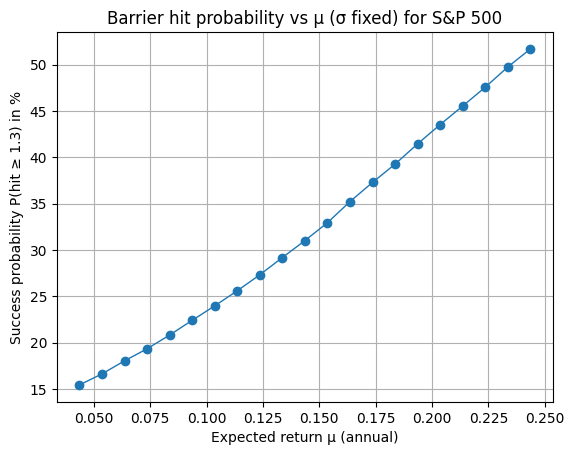

In [55]:
plt.figure()
plt.plot(mu_grid_SP_500 , GMB_grid_Strike_SP_500, marker="o", linewidth=1)
plt.xlabel("Expected return μ (annual)")
plt.ylabel("Success probability P(hit ≥ 1.3) in %")
plt.title("Barrier hit probability vs μ (σ fixed) for S&P 500")
plt.grid(True)
plt.show()

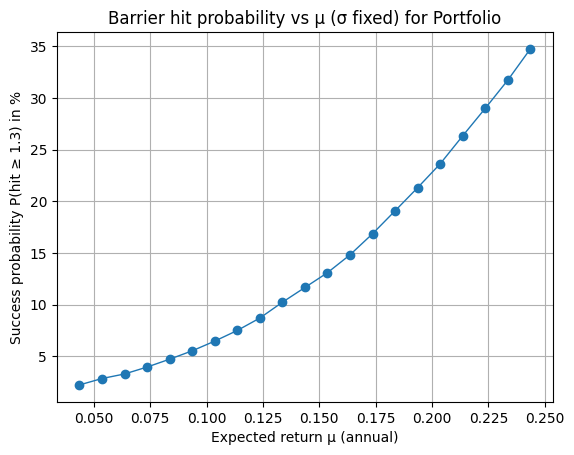

In [54]:
plt.figure()
plt.plot(mu_grid_SP_500 , GMB_grid_Strike_Portfolio, marker="o", linewidth=1)
plt.xlabel("Expected return μ (annual)")
plt.ylabel("Success probability P(hit ≥ 1.3) in %")
plt.title("Barrier hit probability vs μ (σ fixed) for Portfolio")
plt.grid(True)
plt.show()

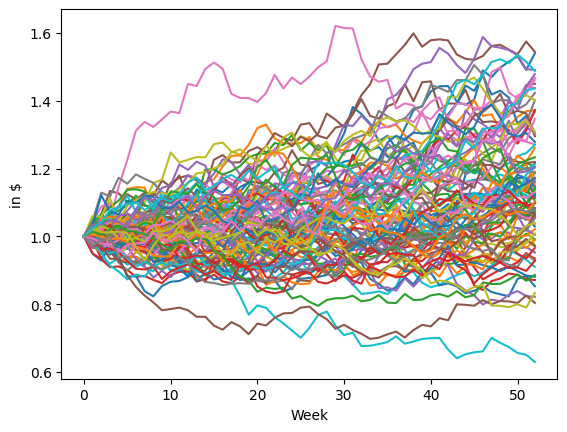

In [29]:
plt.plot(GMB_SP_500[:, 0: 100])
plt.xlabel('Week')
plt.ylabel('in $')
plt.savefig("gbm_sample.pdf")